<a href="https://colab.research.google.com/github/HappyGithub-dev/Customer-Churn-Analysis/blob/main/Kaggle_Houspricing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [2]:
train_df = pd.read_csv('train.csv')
train_df

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,1456,60,RL,62.0,7917,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,8,2007,WD,Normal,175000
1456,1457,20,RL,85.0,13175,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,MnPrv,NaN,0,2,2010,WD,Normal,210000
1457,1458,70,RL,66.0,9042,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,GdPrv,Shed,2500,5,2010,WD,Normal,266500
1458,1459,20,RL,68.0,9717,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,142125


In [3]:
print(train_df.columns)

Index(['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street',
       'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig',
       'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType',
       'HouseStyle', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd',
       'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType',
       'MasVnrArea', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual',
       'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1',
       'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating',
       'HeatingQC', 'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF',
       'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath',
       'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual',
       'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType',
       'GarageYrBlt', 'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual',
       'GarageCond', 'PavedDrive

In [4]:
train_df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [5]:
# Iterate through the columns of the DataFrame
for col in train_df.columns:
    # Check if the column has 'object' data type (usually strings)
    if train_df[col].dtype == 'object':
        # Check if the value 'RL' exists in the unique values of the column
        if 'RL' in train_df[col].unique():
            print(f"Column '{col}' contains the value 'RL'")

Column 'MSZoning' contains the value 'RL'


In [6]:
print(train_df['MSZoning'])

0       RL
1       RL
2       RL
3       RL
4       RL
        ..
1455    RL
1456    RL
1457    RL
1458    RL
1459    RL
Name: MSZoning, Length: 1460, dtype: object


In [7]:
train_df.shape

(1460, 81)

In [8]:
# Select only the numeric columns before calculating correlation
corr_mat = train_df._get_numeric_data().corr()
corr_mat

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
Id,1.000000,0.011156,-0.010601,-0.033226,-0.028365,0.012609,-0.012713,-0.021998,-0.050298,-0.005024,...,-0.029643,-0.000477,0.002889,-0.046635,0.001330,0.057044,-0.006242,0.021172,0.000712,-0.021917
MSSubClass,0.011156,1.000000,-0.386347,-0.139781,0.032628,-0.059316,0.027850,0.040581,0.022936,-0.069836,...,-0.012579,-0.006100,-0.012037,-0.043825,-0.026030,0.008283,-0.007683,-0.013585,-0.021407,-0.084284
LotFrontage,-0.010601,-0.386347,1.000000,0.426095,0.251646,-0.059213,0.123349,0.088866,0.193458,0.233633,...,0.088521,0.151972,0.010700,0.070029,0.041383,0.206167,0.003368,0.011200,0.007450,0.351799
LotArea,-0.033226,-0.139781,0.426095,1.000000,0.105806,-0.005636,0.014228,0.013788,0.104160,0.214103,...,0.171698,0.084774,-0.018340,0.020423,0.043160,0.077672,0.038068,0.001205,-0.014261,0.263843
OverallQual,-0.028365,0.032628,0.251646,0.105806,1.000000,-0.091932,0.572323,0.550684,0.411876,0.239666,...,0.238923,0.308819,-0.113937,0.030371,0.064886,0.065166,-0.031406,0.070815,-0.027347,0.790982
OverallCond,0.012609,-0.059316,-0.059213,-0.005636,-0.091932,1.000000,-0.375983,0.073741,-0.128101,-0.046231,...,-0.003334,-0.032589,0.070356,0.025504,0.054811,-0.001985,0.068777,-0.003511,0.043950,-0.077856
YearBuilt,-0.012713,0.027850,0.123349,0.014228,0.572323,-0.375983,1.000000,0.592855,0.315707,0.249503,...,0.224880,0.188686,-0.387268,0.031355,-0.050364,0.004950,-0.034383,0.012398,-0.013618,0.522897
YearRemodAdd,-0.021998,0.040581,0.088866,0.013788,0.550684,0.073741,0.592855,1.000000,0.179618,0.128451,...,0.205726,0.226298,-0.193919,0.045286,-0.038740,0.005829,-0.010286,0.021490,0.035743,0.507101
MasVnrArea,-0.050298,0.022936,0.193458,0.104160,0.411876,-0.128101,0.315707,0.179618,1.000000,0.264736,...,0.159718,0.125703,-0.110204,0.018796,0.061466,0.011723,-0.029815,-0.005965,-0.008201,0.477493
BsmtFinSF1,-0.005024,-0.069836,0.233633,0.214103,0.239666,-0.046231,0.249503,0.128451,0.264736,1.000000,...,0.204306,0.111761,-0.102303,0.026451,0.062021,0.140491,0.003571,-0.015727,0.014359,0.386420


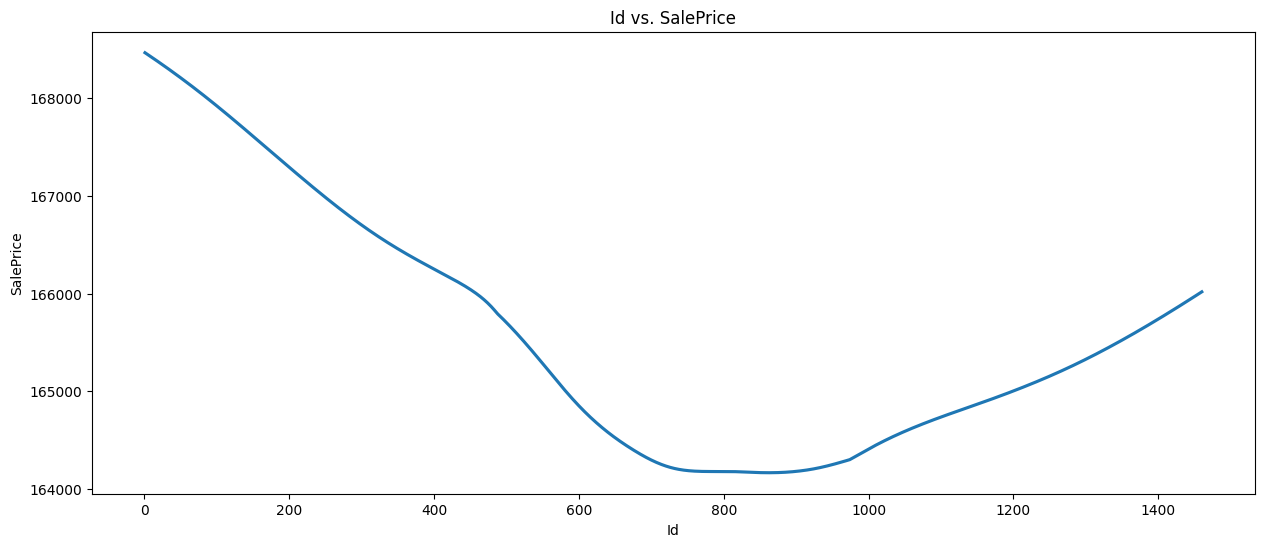

In [9]:
fig, axs = plt.subplots(figsize=(15, 6))

sns.regplot(x='Id', y='SalePrice', data=train_df, scatter=False, ci=None, lowess=True, ax=axs)
axs.set_title('Id vs. SalePrice')
plt.show()

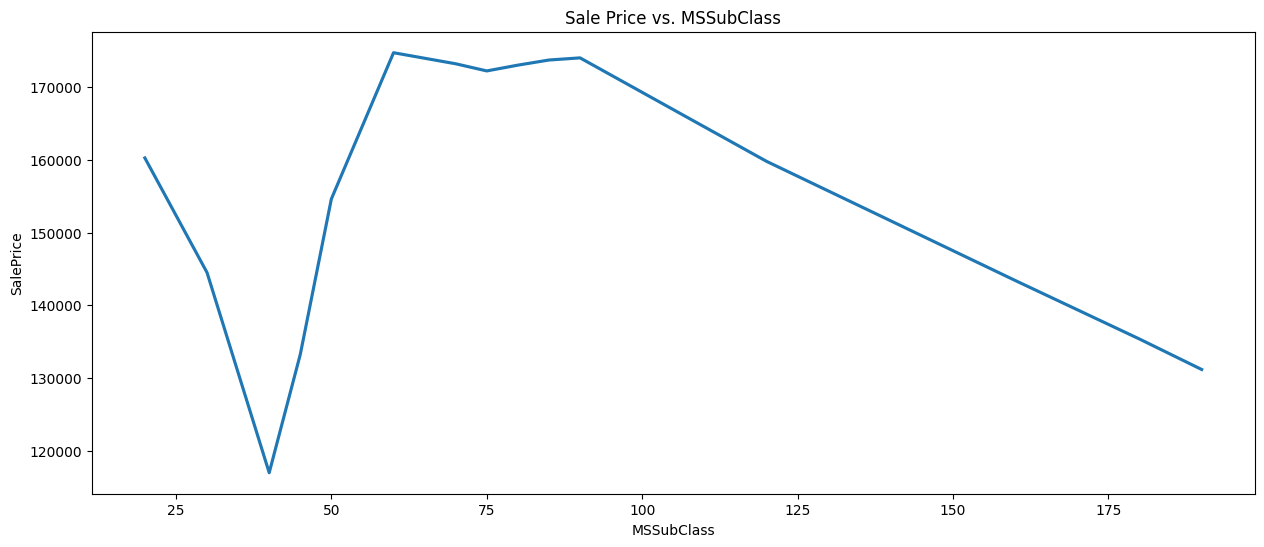

In [10]:
fig, axs = plt.subplots(figsize=(15, 6))

sns.regplot(x='MSSubClass', y='SalePrice', data=train_df, scatter=False, ci=None, lowess=True, ax=axs)
axs.set_title('Sale Price vs. MSSubClass')
plt.show()

In [11]:
train_df['MSSubClass'].describe()

,MSSubClass
count,1460.000000
mean,56.897260
std,42.300571
min,20.000000
25%,20.000000
50%,50.000000
75%,70.000000
max,190.000000


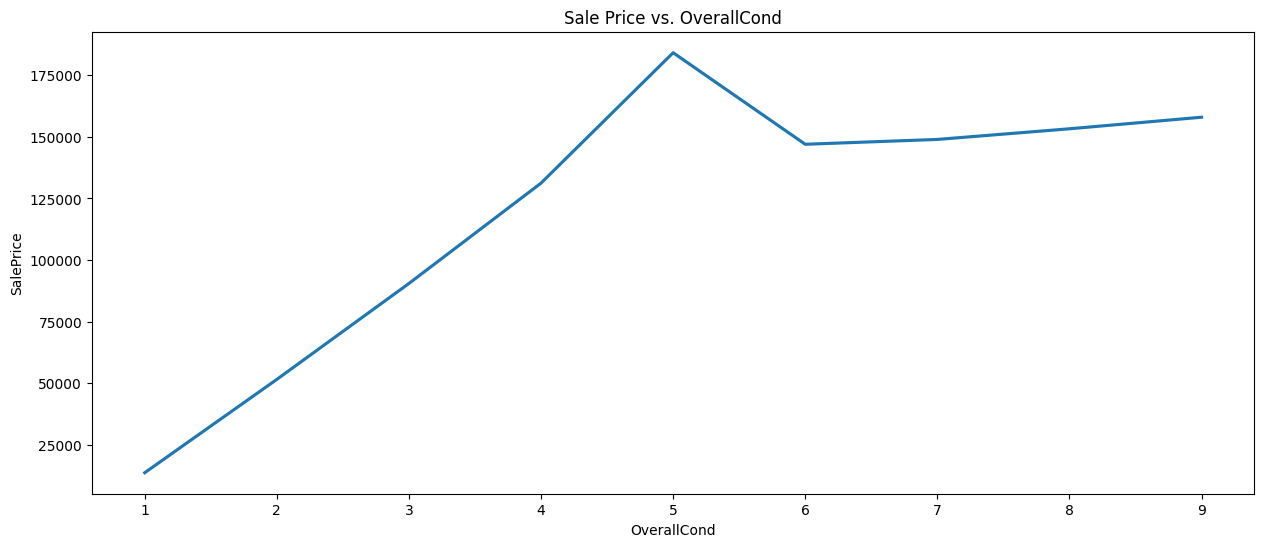

In [12]:
fig, axs = plt.subplots(figsize=(15, 6))

sns.regplot(x='OverallCond', y='SalePrice', data=train_df, scatter=False, ci=None, lowess=True, ax=axs)
axs.set_title('Sale Price vs. OverallCond')
plt.show()

/usr/local/lib/python3.12/dist-packages/statsmodels/nonparametric/smoothers_lowess.py:226: RuntimeWarning: invalid value encountered in divide
  res, _ = _lowess(y, x, x, np.ones_like(x),


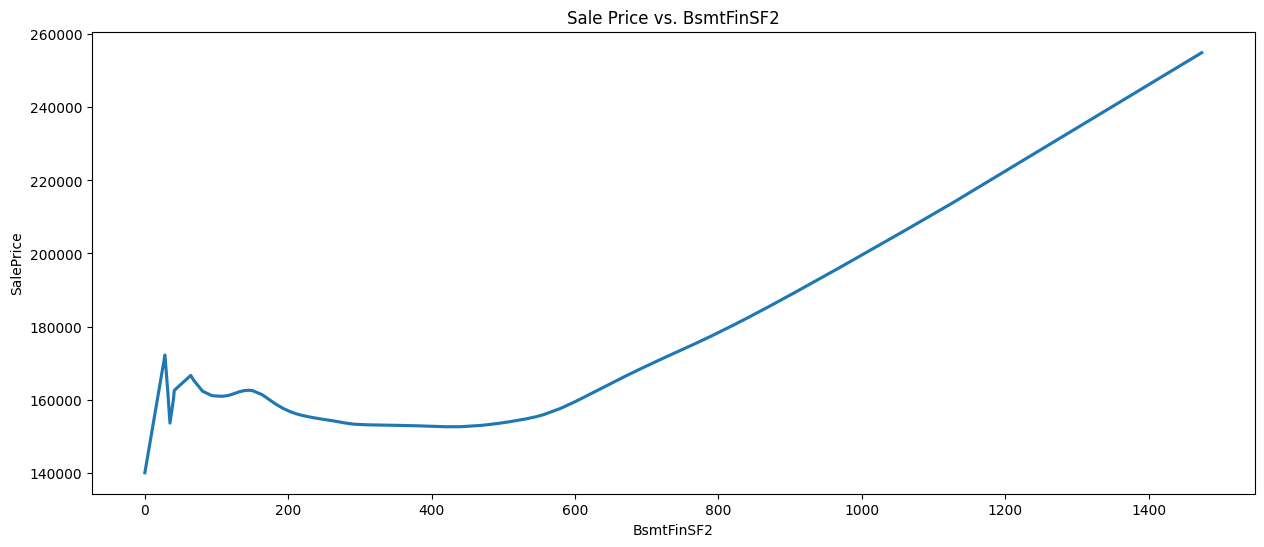

In [13]:
fig, axs = plt.subplots(figsize=(15, 6))

sns.regplot(x='BsmtFinSF2', y='SalePrice', data=train_df, scatter=False, ci=None, lowess=True, ax=axs)
axs.set_title('Sale Price vs. BsmtFinSF2')
plt.show()

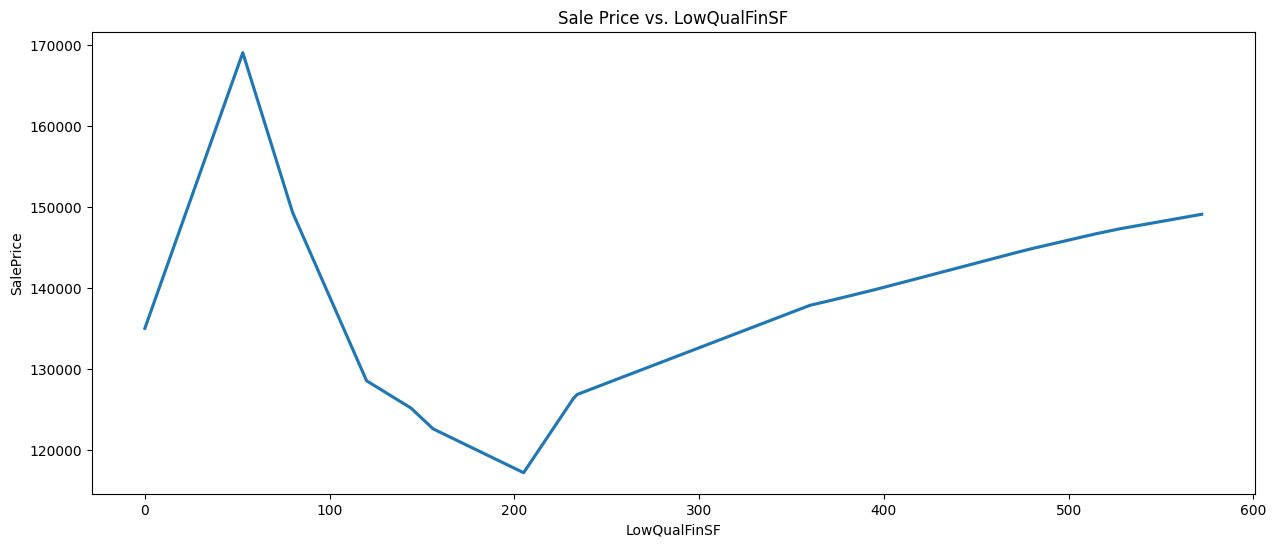

In [14]:
fig, axs = plt.subplots(figsize=(15, 6))

sns.regplot(x='LowQualFinSF', y='SalePrice', data=train_df, scatter=False, ci=None, lowess=True, ax=axs)
axs.set_title('Sale Price vs. LowQualFinSF')
plt.show()

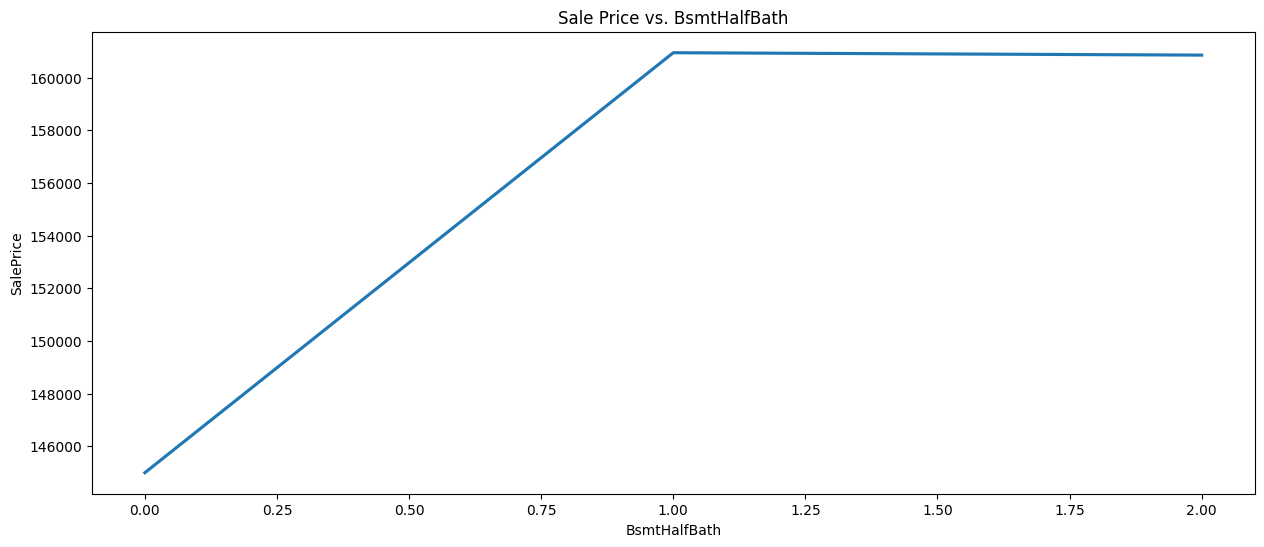

In [15]:
fig, axs = plt.subplots(figsize=(15, 6))

sns.regplot(x='BsmtHalfBath', y='SalePrice', data=train_df, scatter=False, ci=None, lowess=True, ax=axs)
axs.set_title('Sale Price vs. BsmtHalfBath')
plt.show()

In [16]:
train_df['BsmtHalfBath'].describe()

,BsmtHalfBath
count,1460.000000
mean,0.057534
std,0.238753
min,0.000000
25%,0.000000
50%,0.000000
75%,0.000000
max,2.000000


/usr/local/lib/python3.12/dist-packages/statsmodels/nonparametric/smoothers_lowess.py:226: RuntimeWarning: invalid value encountered in divide
  res, _ = _lowess(y, x, x, np.ones_like(x),


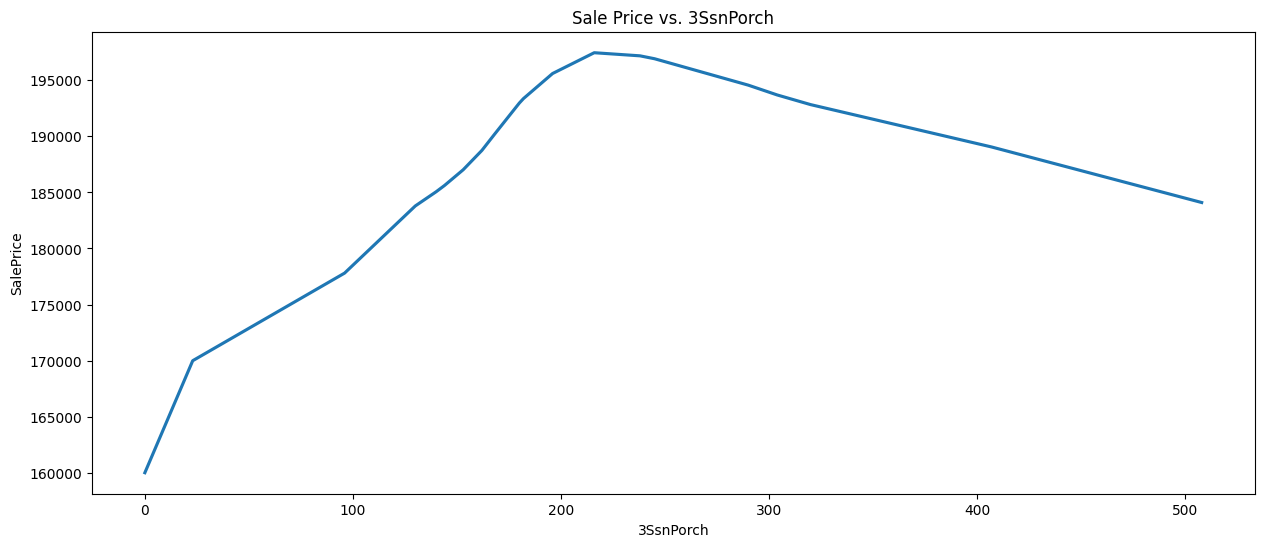

In [17]:
fig, axs = plt.subplots(figsize=(15, 6))

sns.regplot(x='3SsnPorch', y='SalePrice', data=train_df, scatter=False, ci=None, lowess=True, ax=axs)
axs.set_title('Sale Price vs. 3SsnPorch')
plt.show()

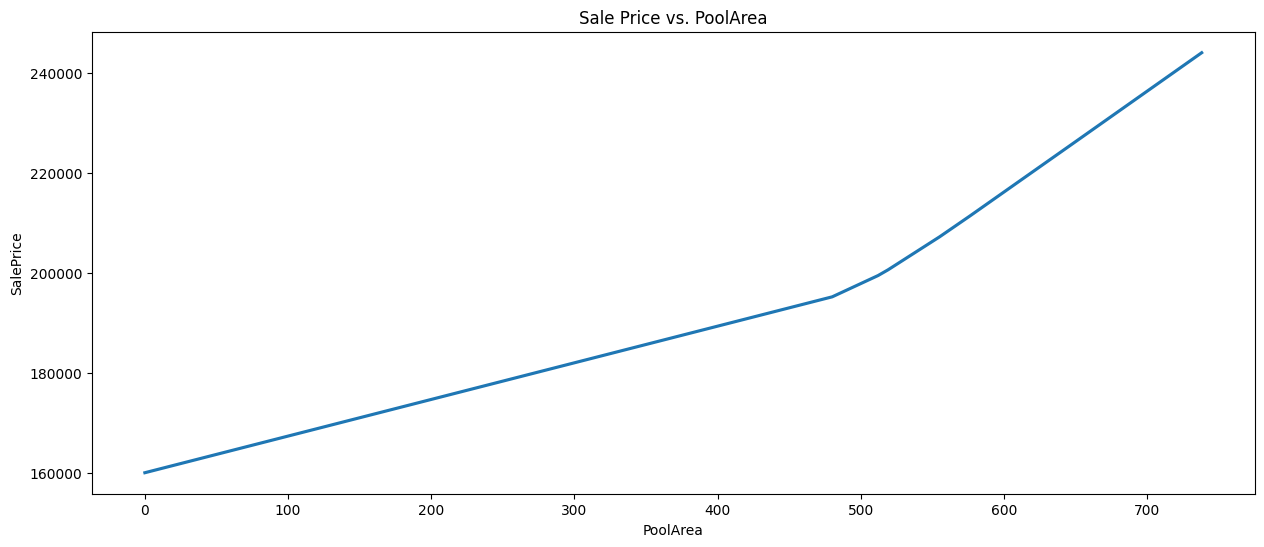

In [18]:
fig, axs = plt.subplots(figsize=(15, 6))

sns.regplot(x='PoolArea', y='SalePrice', data=train_df, scatter=False, ci=None, lowess=True, ax=axs)
axs.set_title('Sale Price vs. PoolArea')
plt.show()

In [19]:
train_df['PoolArea'].describe()

,PoolArea
count,1460.000000
mean,2.758904
std,40.177307
min,0.000000
25%,0.000000
50%,0.000000
75%,0.000000
max,738.000000


/usr/local/lib/python3.12/dist-packages/statsmodels/nonparametric/smoothers_lowess.py:226: RuntimeWarning: invalid value encountered in divide
  res, _ = _lowess(y, x, x, np.ones_like(x),


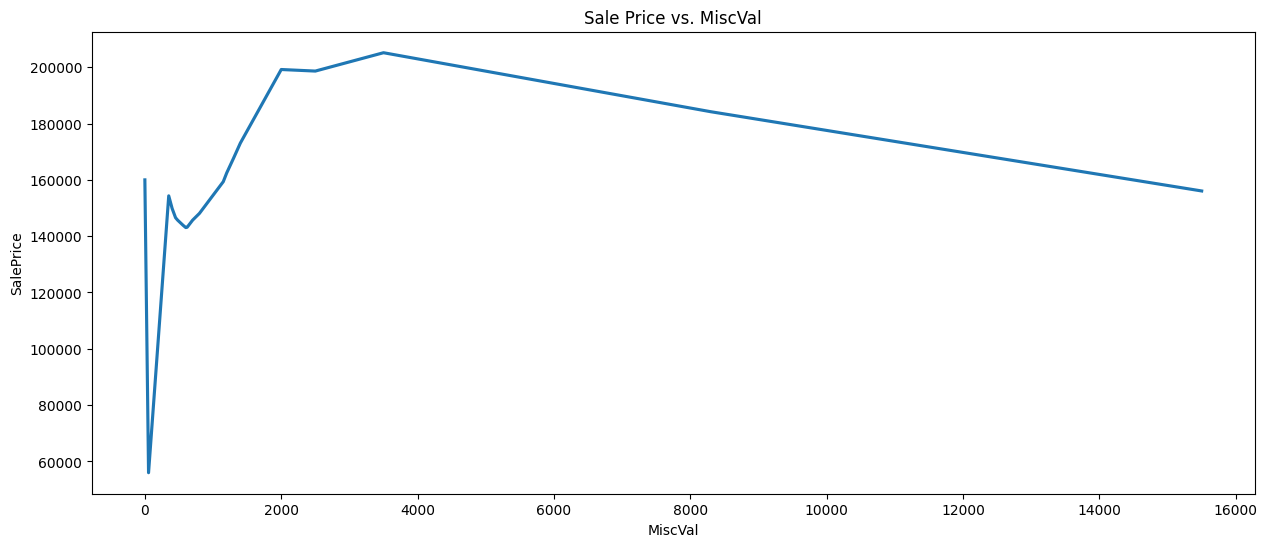

In [20]:
fig, axs = plt.subplots(figsize=(15, 6))

sns.regplot(x='MiscVal', y='SalePrice', data=train_df, scatter=False, ci=None, lowess=True, ax=axs)
axs.set_title('Sale Price vs. MiscVal')
plt.show()

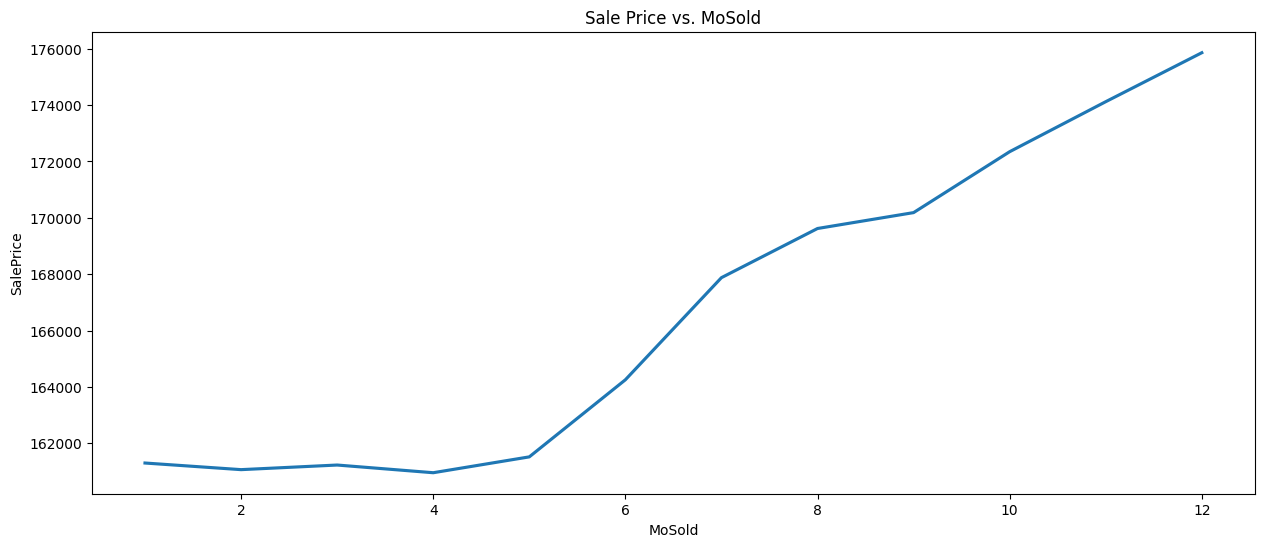

In [21]:
fig, axs = plt.subplots(figsize=(15, 6))

sns.regplot(x='MoSold', y='SalePrice', data=train_df, scatter=False, ci=None, lowess=True, ax=axs)
axs.set_title('Sale Price vs. MoSold')
plt.show()

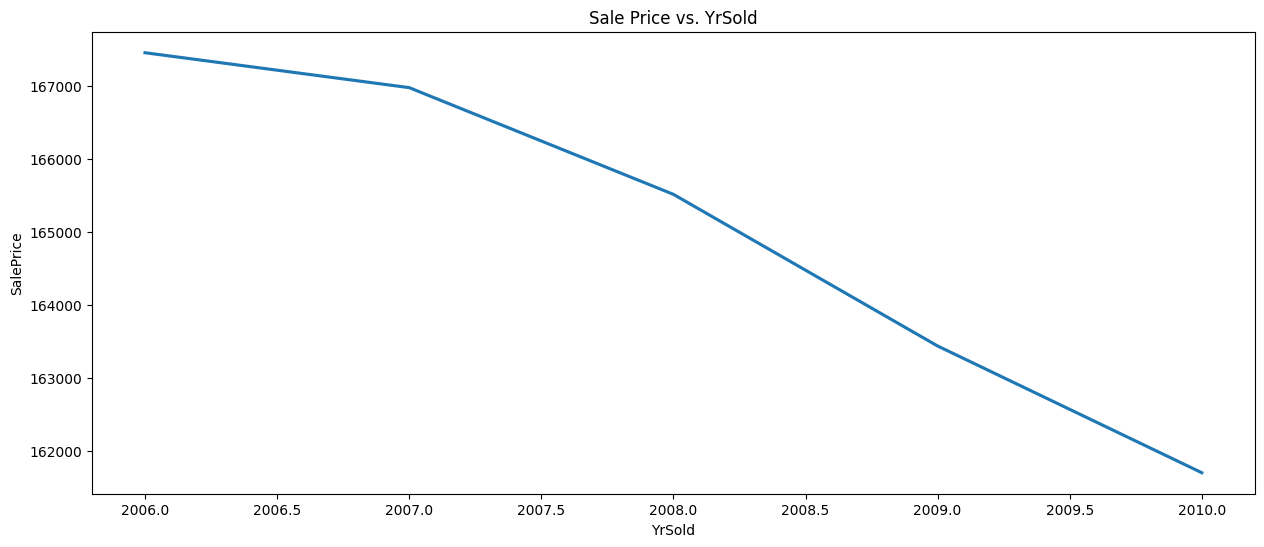

In [22]:
fig, axs = plt.subplots(figsize=(15, 6))

sns.regplot(x='YrSold', y='SalePrice', data=train_df, scatter=False, ci=None, lowess=True, ax=axs)
axs.set_title('Sale Price vs. YrSold')
plt.show()

In [23]:
train_df['YrSold'].describe()

,YrSold
count,1460.000000
mean,2007.815753
std,1.328095
min,2006.000000
25%,2007.000000
50%,2008.000000
75%,2009.000000
max,2010.000000


In [24]:
for col in train_df.select_dtypes(include=np.number).columns:
    if train_df[col].isnull().any():
        train_df[col].fillna(train_df[col].mean(), inplace=True)

for col in train_df.select_dtypes(include='object').columns:
     if train_df[col].isnull().any():
        train_df[col].fillna(train_df[col].mode()[0], inplace=True)

/tmp/ipython-input-2385067937.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  train_df[col].fillna(train_df[col].mean(), inplace=True)
/tmp/ipython-input-2385067937.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)'

In [25]:
nan_counts = train_df.isnull().sum()
print(nan_counts[nan_counts > 0])

Series([], dtype: int64)


In [26]:
## Training the model considering only the nonlinear parameters (as expected from the correlation matrix)

train_df0 = train_df[['MSSubClass','OverallCond','BsmtFinSF2','LowQualFinSF','BsmtHalfBath','3SsnPorch','PoolArea','MiscVal','MoSold','YrSold','SalePrice']]

X_train, X_test, y_train, y_test = train_test_split(train_df0.drop('SalePrice', axis=1), train_df0['SalePrice'], test_size=0.2, random_state=42)

model01 = LinearRegression()
model01.fit(X_train, y_train)

y_pred = model01.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)


print("R-squared:", r2)

R-squared: -0.00037246617972486185


In [27]:
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier

model02 = RandomForestRegressor(n_estimators=100, random_state=42)
model02.fit(X_train, y_train)

y_pred = model02.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)


print("R-squared:", r2)

R-squared: 0.2399721750622229


In [28]:
train_df1 = train_df[['Id','LotFrontage','LotArea','OverallQual','YearBuilt','YearRemodAdd','MasVnrArea','BsmtFinSF1','TotalBsmtSF','1stFlrSF','2ndFlrSF','GrLivArea','BsmtFullBath','FullBath','HalfBath','BedroomAbvGr','TotRmsAbvGrd','Fireplaces','GarageYrBlt','GarageCars','GarageArea','WoodDeckSF','OpenPorchSF','PoolArea','MoSold','YrSold','SalePrice']]

In [29]:
X_train, X_test, y_train, y_test = train_test_split(train_df1.drop('SalePrice', axis=1), train_df1['SalePrice'], test_size=0.2, random_state=42)

In [30]:



from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score, mean_squared_log_error


model11 = LinearRegression()
model11.fit(X_train, y_train)

y_pred = model11.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)


print("R-squared:", r2)
print("Log Error:", mean_squared_log_error(y_test, y_pred))


R-squared: 0.816271676405978
Log Error: 0.039003166348451405


In [31]:
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier

model12 = RandomForestRegressor(n_estimators=100, random_state=42)
model12.fit(X_train, y_train)

y_pred = model12.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)


print("R-squared:", r2)

R-squared: 0.8886418376212244


In [32]:
train_df2 = train_df[['Id','LotFrontage','LotArea','OverallQual','YearBuilt','YearRemodAdd','MasVnrArea','BsmtFinSF1','BsmtUnfSF','TotalBsmtSF','1stFlrSF','2ndFlrSF','GrLivArea','BsmtFullBath','FullBath','HalfBath','BedroomAbvGr','KitchenAbvGr','TotRmsAbvGrd','Fireplaces','GarageYrBlt','GarageCars','GarageArea','WoodDeckSF','OpenPorchSF','EnclosedPorch','PoolArea','MoSold','YrSold','SalePrice']]

In [33]:
X_train, X_test, y_train, y_test = train_test_split(train_df2.drop('SalePrice', axis=1), train_df2['SalePrice'], test_size=0.2, random_state=42)


In [34]:
model21 = LinearRegression()
model21.fit(X_train, y_train)

y_pred = model21.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)


print("R-squared:", r2)

R-squared: 0.8204179992262259


In [35]:
model22 = RandomForestRegressor(n_estimators=100, random_state=42)
model22.fit(X_train, y_train)

y_pred = model22.predict(X_test)

mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)


print("R-squared:", r2)

R-squared: 0.8883082701326971


In [44]:
from sklearn.model_selection import KFold, cross_val_score

X, y = train_df2.drop('SalePrice', axis=1), train_df2['SalePrice']

kf = KFold(n_splits=5, shuffle=True, random_state=42)

model = RandomForestRegressor(n_estimators=100, random_state=42)

scores = cross_val_score(model, X, y, cv=5, scoring='r2')

print("Accuracy scores for each fold:", scores)
print("Mean accuracy:", scores.mean())

Accuracy scores for each fold: [0.86026764 0.83569237 0.86626458 0.87594368 0.80665643]
Mean accuracy: 0.8489649398491999


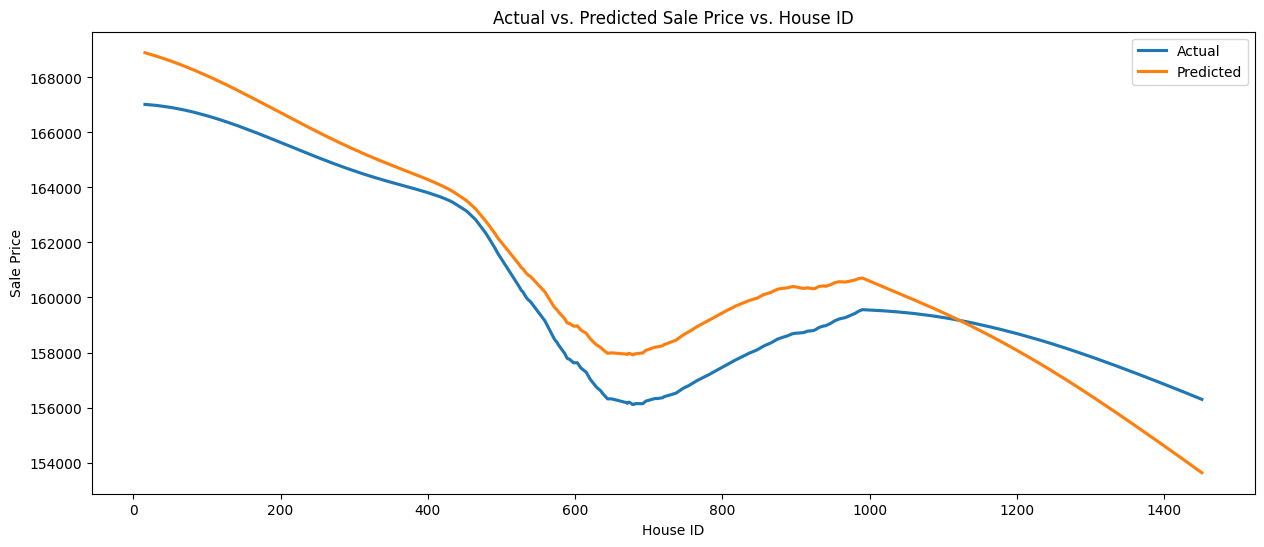

In [36]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

plot_df = pd.DataFrame({'Id': X_test['Id'], 'ActualSalePrice': y_test, 'PredictedSalePrice': y_pred})

plot_df = plot_df.sort_values('Id')

fig, axs = plt.subplots(figsize=(15, 6))

sns.regplot(x='Id', y='ActualSalePrice', data=plot_df, scatter=False, ci=None, lowess=True, label='Actual', ax=axs)

sns.regplot(x='Id', y='PredictedSalePrice', data=plot_df, scatter=False, ci=None, lowess=True, label='Predicted', ax=axs)

axs.set_title('Actual vs. Predicted Sale Price vs. House ID')
axs.set_xlabel('House ID')
axs.set_ylabel('Sale Price')
axs.legend()
plt.show()

In [37]:
##test_df = pd.read_csv('test.csv')

for col in test_df.select_dtypes(include=np.number).columns:
    if test_df[col].isnull().any():
        test_df[col].fillna(test_df[col].mean(), inplace=True)

for col in test_df.select_dtypes(include='object').columns:
     if test_df[col].isnull().any():
        test_df[col].fillna(test_df[col].mode()[0], inplace=True)

test_df_features = test_df[['Id','LotFrontage','LotArea','OverallQual','YearBuilt','YearRemodAdd','MasVnrArea','BsmtFinSF1','BsmtUnfSF','TotalBsmtSF','1stFlrSF','2ndFlrSF','GrLivArea','BsmtFullBath','FullBath','HalfBath','BedroomAbvGr','KitchenAbvGr','TotRmsAbvGrd','Fireplaces','GarageYrBlt','GarageCars','GarageArea','WoodDeckSF','OpenPorchSF','EnclosedPorch','PoolArea','MoSold','YrSold']]

test_predictions = model22.predict(test_df_features)

submission_df = pd.DataFrame({'Id': test_df['Id'], 'SalePrice': test_predictions})

submission_df.to_csv('submission.csv', index=False)

print("Submission file 'submission.csv' created successfully!")

FileNotFoundError: [Errno 2] No such file or directory: 'test.csv'